# Exploratory data analysis, two variables at a time

**Master in Healthcare Analytics · Session: Bivariate EDA**
Dataset: Outpatient appointments, Riverbend Community Hospital (fictional), calendar year 2025.

The previous session described variables one at a time. This one asks the question that usually matters more: **how do two variables relate to each other?** The tools depend on what kind of variables they are:

| Pair | Main tools | Where |
|---|---|---|
| Continuous × continuous | scatterplot, correlation coefficient, correlation matrix | Part A |
| Continuous × discrete | grouped summary table, side-by-side boxplots, overlaid histograms | Part B |

We stay descriptive throughout. No hypothesis tests and no fitted lines; those come in the next sessions.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, YELLOW, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})

appointments = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/appointments.csv", parse_dates=["booking_date", "appointment_date"])
patients = pd.read_csv(" https://raw.githubusercontent.com/thousandoaks/Maths4DS-I/refs/heads/main/data/patients.csv")
print(appointments.shape, patients.shape)

(79253, 18) (11523, 7)


---
# Part A — Two continuous variables

## A1. Why we need a patient-level table

The three continuous columns in `appointments.csv` (age, distance, lead time) describe different things and, in this hospital, are not related to one another: a patient's age tells you nothing about how far away they live or how far ahead their appointments are booked. We could compute their correlations and find values near zero, which is a valid finding but not an instructive one.

The relationships in this dataset are about **attendance**. To study attendance as a continuous quantity we need to move from one row per appointment to **one row per patient**, and compute for each patient:

- how many appointments they had (excluding cancellations),
- how many they missed,
- their **no-show rate** (missed ÷ appointments),
- their **mean lead time**,
- and carry over their age and distance, which are fixed per patient.

This is done with `groupby`: split the appointments by patient, compute a summary for each group, and collect the results into a new table. It is the single most useful operation in pandas and worth reading slowly.

In [2]:
# 1. keep appointments that were not cancelled, and flag the no-shows
kept = appointments[appointments["status"].isin(["Arrived", "No-show"])].copy()
kept["no_show"] = (kept["status"] == "No-show").astype(int)

# 2. one row per patient
per_patient = kept.groupby("patient_id").agg(
    appointments=("no_show", "size"),       # number of rows for this patient
    no_shows=("no_show", "sum"),            # number of 1s
    no_show_rate=("no_show", "mean"),       # share of 1s
    mean_lead_time=("lead_time_days", "mean"),
)

# 3. add the patient's fixed attributes
per_patient = per_patient.join(patients.set_index("patient_id")[["age", "distance_miles"]])

print(per_patient.shape)
per_patient.head()

(11403, 6)


,appointments,no_shows,no_show_rate,mean_lead_time,age,distance_miles
patient_id,,,,,,
P000001,4,1,0.250000,4.750000,18,9.2
P000002,19,2,0.105263,19.473684,52,5.2
P000003,1,0,0.000000,7.000000,42,4.0
P000004,3,0,0.000000,14.666667,32,2.3
P000005,1,0,0.000000,10.000000,18,3.9


One row per patient, six numeric columns. Note that `no_show_rate` for a patient with two appointments can only be 0, 0.5 or 1, so it is a noisy measure for patients with few visits. That is a limitation to keep in mind, not a reason to stop.

## A2. Start with one pair: a scatterplot

A **scatterplot** puts one variable on each axis and one point per row. It is the first thing to draw for any pair of continuous variables, before computing anything, because it shows the *form* of a relationship (straight, curved, none), its *strength* (tight or diffuse), and any *oddities* (clusters, outliers, caps).

Start with the pair we expect to be related: how many appointments a patient had and how many they missed.

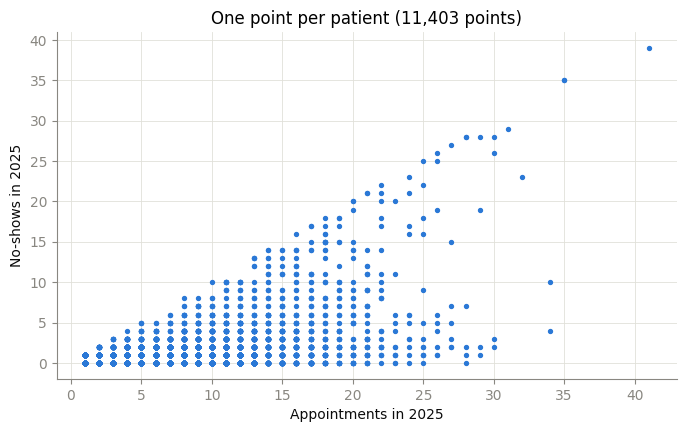

In [3]:
fig, ax = plt.subplots()
ax.scatter(per_patient["appointments"], per_patient["no_shows"], s=8, color=BLUE)
ax.set_xlabel("Appointments in 2025"); ax.set_ylabel("No-shows in 2025")
ax.set_title("One point per patient (11,403 points)")
plt.show()

The plot has a problem that every real dataset has: with thousands of patients and whole-number values, many points sit exactly on top of one another, so we cannot tell whether a spot holds one patient or five hundred. Two standard fixes:

- **Transparency** (`alpha`): overlapping points build up into darker areas, so density becomes visible.
- **Jitter**: add a small random shift to each point so that identical values spread out slightly.

We use both.

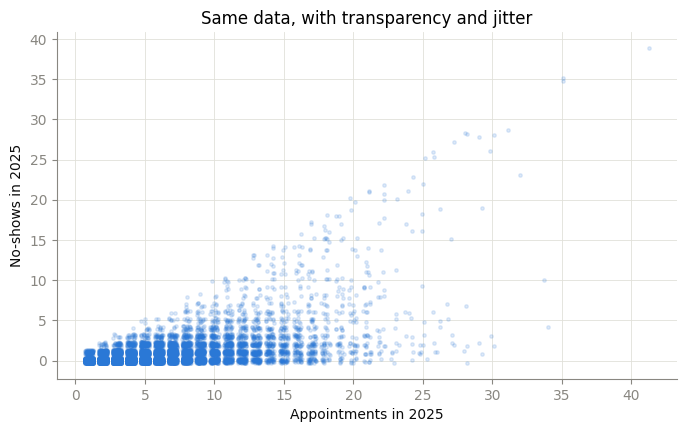

In [4]:
rng = np.random.default_rng(0)
jx = per_patient["appointments"] + rng.uniform(-0.3, 0.3, len(per_patient))
jy = per_patient["no_shows"] + rng.uniform(-0.3, 0.3, len(per_patient))

fig, ax = plt.subplots()
ax.scatter(jx, jy, s=6, color=BLUE, alpha=0.15)
ax.set_xlabel("Appointments in 2025"); ax.set_ylabel("No-shows in 2025")
ax.set_title("Same data, with transparency and jitter")
plt.show()

Now the structure is visible: a dense mass of patients with few appointments and few no-shows, a clear upward drift (patients with more appointments miss more, in absolute terms), and a fan shape: the spread of no-shows widens as the number of appointments grows. The relationship is positive and moderately strong, but far from a straight line.

## A3. Putting a number on it: the correlation coefficient

The **Pearson correlation coefficient**, written *r*, summarises how closely two variables follow a straight line. It runs from −1 (perfect straight line going down) through 0 (no linear relationship) to +1 (perfect straight line going up). Rough conventions: |r| below 0.1 is negligible, 0.1–0.3 weak, 0.3–0.5 moderate, above 0.5 strong. These are conventions, not laws; the scatterplot always has the final word.

In [5]:
r = per_patient["appointments"].corr(per_patient["no_shows"])
print(f"Pearson r between appointments and no-shows: {r:.2f}")

Pearson r between appointments and no-shows: 0.55


A correlation of 0.55: strong by convention. But think about *why* before being impressed. A patient who had twenty appointments has had twenty chances to miss one; a patient with two has had two. Some of this correlation is **mechanical**: it exists because of how the two quantities are defined, not because of anything about the patients. This is the first of the standard warnings about correlation, and it is why we also computed the no-show *rate*, which removes the number of chances from the picture.

## A4. Weaker relationships look very different

Compare three pairs side by side, each with its *r*: no-show rate against age, against distance, and age against distance. Rates are noisy for patients with few appointments, so for these plots we keep patients with at least five.

Patients with 5+ appointments: 6582


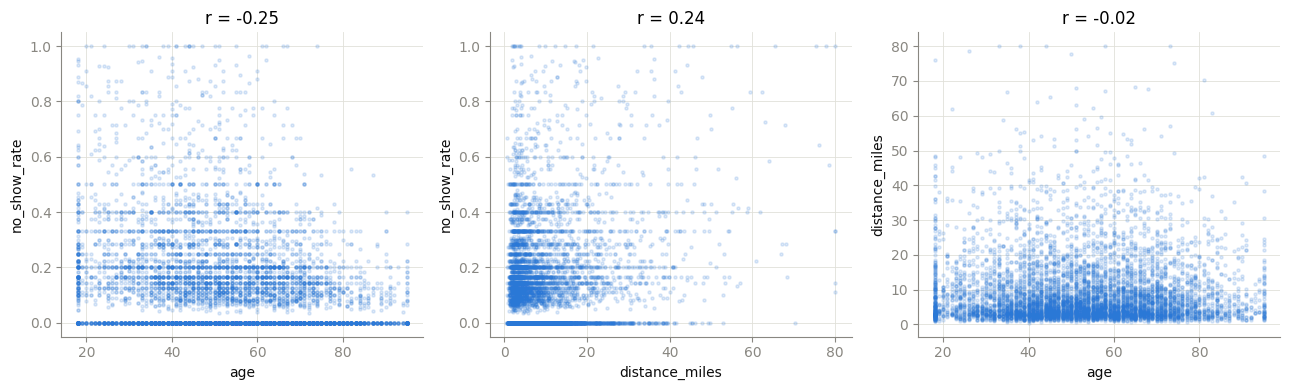

In [6]:
regular = per_patient[per_patient["appointments"] >= 5]
print("Patients with 5+ appointments:", len(regular))

pairs = [("age", "no_show_rate"), ("distance_miles", "no_show_rate"), ("age", "distance_miles")]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (x, y) in zip(axes, pairs):
    r = regular[x].corr(regular[y])
    ax.scatter(regular[x], regular[y], s=5, color=BLUE, alpha=0.15)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f"r = {r:.2f}")
plt.tight_layout(); plt.show()

Three lessons from one row of plots:

- **Age vs no-show rate, r ≈ −0.25.** Weak-to-moderate and negative: older patients miss slightly fewer appointments. The cloud tilts down so gently that you would not see it without the number.
- **Distance vs no-show rate, r ≈ +0.24.** Weak-to-moderate and positive: patients who live farther away miss slightly more. Note that most patients are bunched at short distances, with a sparse tail to the right.
- **Age vs distance, r ≈ 0.** No relationship at all: the cloud is a shapeless blob. This is what "uncorrelated" looks like.

Weak correlations are the normal case in healthcare data. A single factor rarely explains much on its own; the useful question is usually whether several weak factors add up.

## A5. All pairs at once: the correlation matrix

With six variables there are fifteen pairs. Rather than fifteen scatterplots, compute every pairwise *r* in one table with `.corr()`, and show it as a coloured grid (a **heatmap**). The diagonal is always 1 (a variable correlated with itself); the matrix is symmetric, so only one half needs reading.

In [7]:
corr = regular.corr().round(2)
corr

,appointments,no_shows,no_show_rate,mean_lead_time,age,distance_miles
appointments,1.00,0.53,0.25,-0.00,0.01,0.00
no_shows,0.53,1.00,0.85,0.20,-0.18,0.18
no_show_rate,0.25,0.85,1.00,0.29,-0.25,0.24
mean_lead_time,-0.00,0.20,0.29,1.00,-0.06,-0.01
age,0.01,-0.18,-0.25,-0.06,1.00,-0.02
distance_miles,0.00,0.18,0.24,-0.01,-0.02,1.00


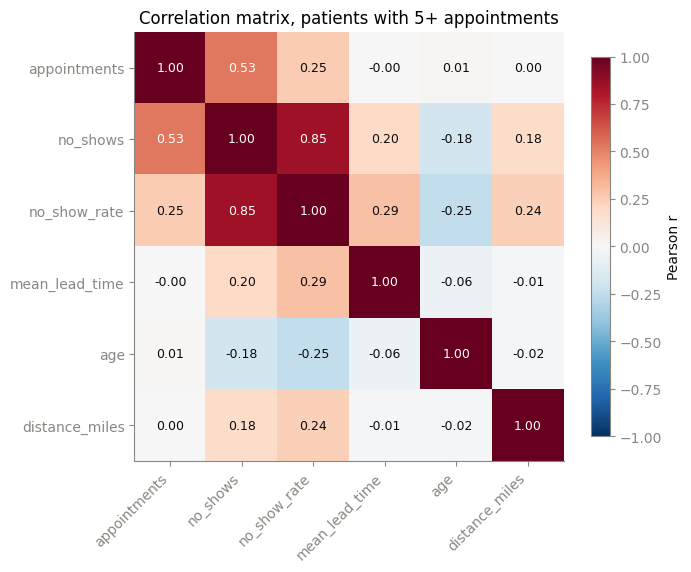

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.columns)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation matrix, patients with 5+ appointments")
plt.tight_layout(); plt.show()

How to read it: look for the cells that are clearly coloured and ask, for each, whether the relationship is interesting or mechanical.

- `no_shows` ↔ `no_show_rate` and `no_shows` ↔ `appointments` are strong and **mechanical** (one is computed from the other).
- `no_show_rate` ↔ `mean_lead_time` is a real, moderate finding: patients whose appointments are booked further ahead miss more of them.
- `no_show_rate` ↔ `age` (negative, about −0.25) and ↔ `distance_miles` (positive, about +0.24) are weak-to-moderate but real.
- Everything involving `age` ↔ `distance` or `mean_lead_time` ↔ `age` is near zero: unrelated.

A correlation matrix is a map, not a result. It tells you which pairs deserve a scatterplot, and which do not.

## A6. Pearson or Spearman?

Pearson's *r* measures how close the points are to a *straight line*, and it is sensitive to skewed variables and extreme values. **Spearman's** correlation does the same computation on the *ranks* of the values instead of the values themselves, so it measures whether the relationship is consistently increasing or decreasing, whatever its shape, and is not pulled around by outliers. For skewed variables such as distance and lead time, it is worth computing both.

In [9]:
pearson = regular[["no_show_rate", "mean_lead_time", "distance_miles", "age"]].corr()
spearman = regular[["no_show_rate", "mean_lead_time", "distance_miles", "age"]].corr(method="spearman")
comparison = pd.DataFrame({"Pearson r": pearson["no_show_rate"], "Spearman rho": spearman["no_show_rate"]}).drop("no_show_rate").round(2)
comparison

,Pearson r,Spearman rho
mean_lead_time,0.29,0.26
distance_miles,0.24,0.16
age,-0.25,-0.24


The two agree on sign and broadly on size, which is reassuring. Where they differ noticeably, the variable is usually skewed or has outliers, and the scatterplot will show why.

## A7. Two warnings that always apply

**Correlation is not causation.** Distance correlates with missing appointments. Does living far away *cause* no-shows? Plausibly, through travel burden. But patients who live far away are also more often on Medicaid, and more often rural, and rural patients may have other reasons to miss visits. The correlation is real; the explanation is not settled by the number.

**Correlation measures straight lines only.** Two variables can be strongly related in a curved way and have r ≈ 0. Always draw the scatterplot.

---
# Part B — A continuous variable across groups

## B1. The question

Does **lead time** differ between the four **clinics**? Operationally this is the question "where are the waiting lists?", and the answer decides where extra capacity would help. The continuous variable is `lead_time_days`; the discrete one is `clinic`. We go back to the appointment-level table, since lead time belongs to the appointment.

## B2. A grouped summary table

The numeric starting point is the same summary as in the univariate session, computed **within each group**. `groupby("clinic")` splits the table; `describe()` summarises each piece. We add the 90th percentile, since the tail is what waiting-list discussions are about.

In [10]:
order = ["Family Medicine", "Internal Medicine", "Orthopedics", "Cardiology"]

summary = appointments.groupby("clinic")["lead_time_days"].describe()
summary["P90"] = appointments.groupby("clinic")["lead_time_days"].quantile(0.9)
summary = summary.loc[order, ["count", "mean", "50%", "P90", "std", "min", "max"]].rename(columns={"50%": "median"})
summary.round(1)

,count,mean,median,P90,std,min,max
clinic,,,,,,,
Family Medicine,30563.0,9.0,7.0,18.0,7.7,0.0,120.0
Internal Medicine,24540.0,13.7,10.0,27.0,11.6,0.0,120.0
Orthopedics,11622.0,21.5,17.0,41.0,17.0,1.0,120.0
Cardiology,12528.0,30.7,24.0,61.0,23.2,2.0,120.0


The table already tells most of the story. The median wait more than triples from Family Medicine (7 days) to Cardiology (24 days), and the tail grows faster still: one Cardiology appointment in ten is booked more than two months ahead. Note also the `count` column: the groups are of different sizes, which is normal and does not prevent comparison, but matters when a group is very small.

## B3. Side-by-side boxplots

The standard picture for a continuous variable across groups. One box per group, on a common axis, so that medians, spreads and tails can be compared at a glance. Order the groups sensibly: here by median, which also happens to be primary care first, specialty care last.

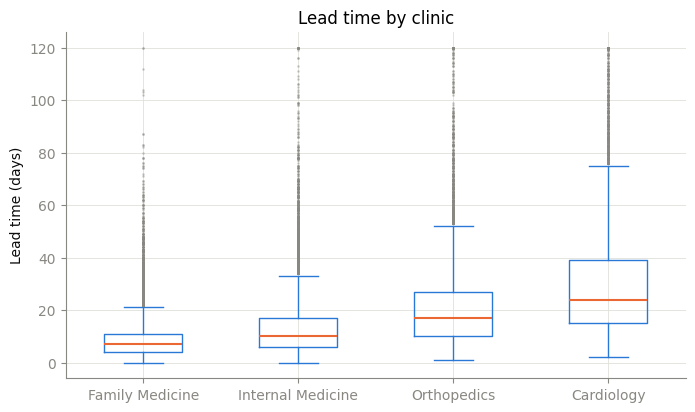

In [11]:
fig, ax = plt.subplots()
ax.boxplot([appointments.loc[appointments["clinic"] == c, "lead_time_days"] for c in order],
           tick_labels=order, widths=0.5, medianprops=dict(color=ORANGE, linewidth=1.5),
           boxprops=dict(color=BLUE), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
           flierprops=dict(marker=".", markersize=2, markerfacecolor=MUTED, markeredgecolor=MUTED, alpha=0.3))
ax.set_ylabel("Lead time (days)"); ax.set_title("Lead time by clinic")
plt.show()

Reading left to right: each box sits higher and is taller than the last. The medians (orange) separate cleanly; the boxes barely overlap between primary care and specialty clinics. The clouds of points above the whiskers are the long-wait tails, largest in Cardiology.

Boxplots are excellent for comparison and poor at showing *shape*. Every clinic here is right-skewed, but a boxplot cannot show whether a distribution has one peak or two. When shape matters, overlay histograms.

## B4. Overlaid histograms for two groups

Pick the two extremes and draw their lead-time distributions on the same axes. Because the groups have different sizes, plot **density** (area = 1) rather than counts, so the shapes are comparable.

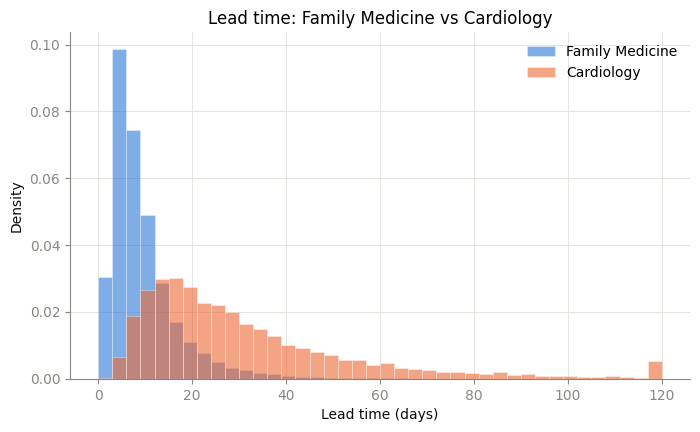

In [12]:
fm = appointments.loc[appointments["clinic"] == "Family Medicine", "lead_time_days"]
ca = appointments.loc[appointments["clinic"] == "Cardiology", "lead_time_days"]

fig, ax = plt.subplots()
bins = range(0, 122, 3)
ax.hist(fm, bins=bins, density=True, color=BLUE, alpha=0.6, edgecolor="white", linewidth=0.4, label="Family Medicine")
ax.hist(ca, bins=bins, density=True, color=ORANGE, alpha=0.6, edgecolor="white", linewidth=0.4, label="Cardiology")
ax.set_xlabel("Lead time (days)"); ax.set_ylabel("Density"); ax.set_title("Lead time: Family Medicine vs Cardiology")
ax.legend(frameon=False); plt.show()

Now the difference is visible as a *shift*: the whole Cardiology distribution sits to the right, with the same right-skewed shape stretched out. Nothing suggests two kinds of Cardiology appointment (which would show as two peaks). Overlaying works well for two or three groups; beyond that, use boxplots or one small histogram per group.

## B5. The same tools, another grouping: visit type

Once the procedure is clear, applying it to another discrete variable is quick. Is lead time different by visit type?

                 count  median  mean   P90
visit_type                                
Telehealth       10724     5.0   7.0  14.0
Established      43233    10.0  14.1  29.0
Annual wellness   9476    13.5  18.7  38.0
New patient      15820    18.0  24.3  51.0


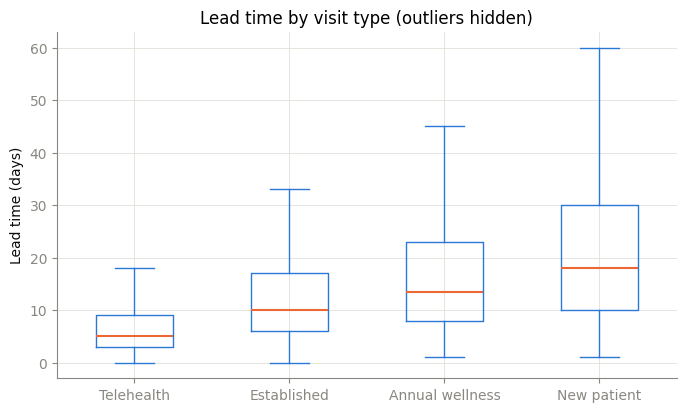

In [13]:
vt_order = ["Telehealth", "Established", "Annual wellness", "New patient"]
vt = appointments.groupby("visit_type")["lead_time_days"].agg(["count", "median", "mean"])
vt["P90"] = appointments.groupby("visit_type")["lead_time_days"].quantile(0.9)
print(vt.loc[vt_order].round(1))

fig, ax = plt.subplots()
ax.boxplot([appointments.loc[appointments["visit_type"] == v, "lead_time_days"] for v in vt_order],
           tick_labels=vt_order, widths=0.5, showfliers=False, medianprops=dict(color=ORANGE, linewidth=1.5),
           boxprops=dict(color=BLUE), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.set_ylabel("Lead time (days)"); ax.set_title("Lead time by visit type (outliers hidden)")
plt.show()

Telehealth visits are booked with the shortest notice (median 5 days) and new-patient visits the longest (18 days). This time we hid the outlier points (`showfliers=False`) to keep the boxes readable; that is a presentation choice and should be stated in the caption, as here.

## B6. Reversing the roles: lead time by outcome

So far the discrete variable was a *characteristic* (clinic, visit type) and we asked how the continuous variable varied across it. The same tools answer the reverse question: does the continuous variable differ between **outcomes**? Compare lead time for appointments that were attended and those that were missed.

         count  median  mean   P90
status                            
Arrived  61303    10.0  14.1  29.0
No-show  10738    16.0  23.8  55.0


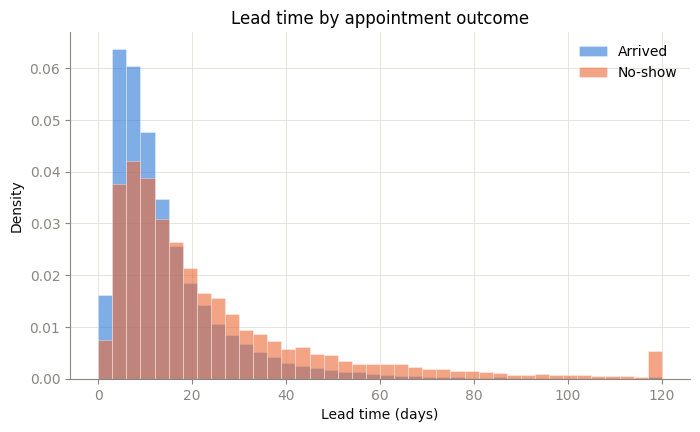

In [14]:
kept_order = ["Arrived", "No-show"]
by_status = kept.groupby("status")["lead_time_days"].agg(["count", "median", "mean"])
by_status["P90"] = kept.groupby("status")["lead_time_days"].quantile(0.9)
print(by_status.loc[kept_order].round(1))

fig, ax = plt.subplots()
bins = range(0, 122, 3)
ax.hist(kept.loc[kept["status"] == "Arrived", "lead_time_days"], bins=bins, density=True,
        color=BLUE, alpha=0.6, edgecolor="white", linewidth=0.4, label="Arrived")
ax.hist(kept.loc[kept["status"] == "No-show", "lead_time_days"], bins=bins, density=True,
        color=ORANGE, alpha=0.6, edgecolor="white", linewidth=0.4, label="No-show")
ax.set_xlabel("Lead time (days)"); ax.set_ylabel("Density"); ax.set_title("Lead time by appointment outcome")
ax.legend(frameon=False); plt.show()

Missed appointments were booked further ahead: median 16 days against 10 for attended ones, and the whole no-show distribution is shifted right. This is the descriptive form of the finding that will become, in later sessions, "lead time predicts no-shows". For now it is an association seen in a picture, and the two warnings from Part A apply to it just as much.

---
# Summary

| Situation | Look at | Compute | Watch for |
|---|---|---|---|
| Two continuous variables | scatterplot (with transparency or jitter when points overlap) | Pearson *r*; Spearman when skewed; correlation matrix for many pairs | mechanical correlations, curved relationships, outliers, causation claims |
| Continuous variable across groups | side-by-side boxplots; overlaid histograms for 2–3 groups | grouped summary table with median and P90 | unequal group sizes, hidden shape differences, group ordering |

Two habits to keep. **Draw before you compute**: a correlation coefficient or a group mean without the picture behind it is easy to misread. And **ask why a relationship exists before reporting it**: some correlations are built into the definitions of the variables, and a difference between groups can come from what the groups contain rather than from the grouping itself.